In [4]:
%pip install scikit-learn pandas matplotlib optuna h5py

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Lily\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [6]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import optuna
import sklearn

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("h5py:", h5py.__version__)
print("Optuna:", optuna.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.4.6
Pandas: 3.0.5
h5py: 3.16.0
Optuna: 5.0.0
Scikit-learn: 1.9.1


In [7]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [8]:
# Abre o arquivo HDF5 e lista os datasets armazenados nele

arquivo = "3D MNIST/full_dataset_vectors.h5"

with h5py.File(arquivo, "r") as f:
    print("Conteúdo do arquivo:")
    print(list(f.keys()))

Conteúdo do arquivo:
['X_test', 'X_train', 'y_test', 'y_train']


In [9]:
# Mostra o formato e o tipo de dado de cada dataset dentro do arquivo HDF5

with h5py.File(arquivo, "r") as f:
    for chave in f.keys():
        dataset = f[chave]

        print(
            f"{chave}: "
            f"shape={dataset.shape}, "
            f"dtype={dataset.dtype}"
        )

X_test: shape=(2000, 4096), dtype=float64
X_train: shape=(10000, 4096), dtype=float64
y_test: shape=(2000,), dtype=int64
y_train: shape=(10000,), dtype=int64


In [10]:
# Carrega os dados de treinamento e teste armazenados no arquivo HDF5

with h5py.File(arquivo, "r") as f:
    X_train = f["X_train"][:]
    y_train = f["y_train"][:]
    X_test = f["X_test"][:]
    y_test = f["y_test"][:]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10000, 4096)
y_train: (10000,)
X_test: (2000, 4096)
y_test: (2000,)


X_train = atributos usados para treinamento
y_train = respostas corretas do treinamento

X_test = atributos reservados para o teste final
y_test = respostas corretas do teste final

In [11]:
# Identifica as classes do conjunto de treinamento e conta quantos exemplos existem em cada classe

classes, quantidades = np.unique(
    y_train,
    return_counts=True
)

distribuicao = pd.DataFrame({
    "Classe": classes,
    "Quantidade": quantidades
})

distribuicao

,Classe,Quantidade
0,0,958
1,1,1126
2,2,976
3,3,986
4,4,1070
5,5,868
6,6,1002
7,7,1100
8,8,924
9,9,990


In [12]:
# Verifica valores ausentes e analisa a escala dos atributos do conjunto de treinamento

print("Valores ausentes:", np.isnan(X_train).sum())
print("Valor mínimo:", X_train.min())
print("Valor máximo:", X_train.max())
print("Média:", X_train.mean())
print("Desvio padrão:", X_train.std())

Valores ausentes: 0
Valor mínimo: 0.0
Valor máximo: 1.0
Média: 0.06742186928169411
Desvio padrão: 0.17518264756674443


Importante analizar:

- Há NaN?
- Os valores vão de 0 a 1?
- Vão de 0 a 255?
- Existem valores negativos?
- Todos os atributos estão aproximadamente na mesma escala?

In [13]:
# Exibe os primeiros valores de uma amostra e sua classe correta

indice = 0

print("Primeiros 30 atributos:")
print(X_train[indice][:30])

print("\nQuantidade total de atributos:")
print(len(X_train[indice]))

print("\nClasse correta:")
print(y_train[indice])

Primeiros 30 atributos:
[0.         0.         0.         0.         0.         0.8372093
 0.8372093  0.8372093  0.8372093  0.8372093  0.8372093  0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.62790698 0.41860465 0.41860465
 0.41860465 0.41860465 0.62790698 0.         0.         0.        ]

Quantidade total de atributos:
4096

Classe correta:
5


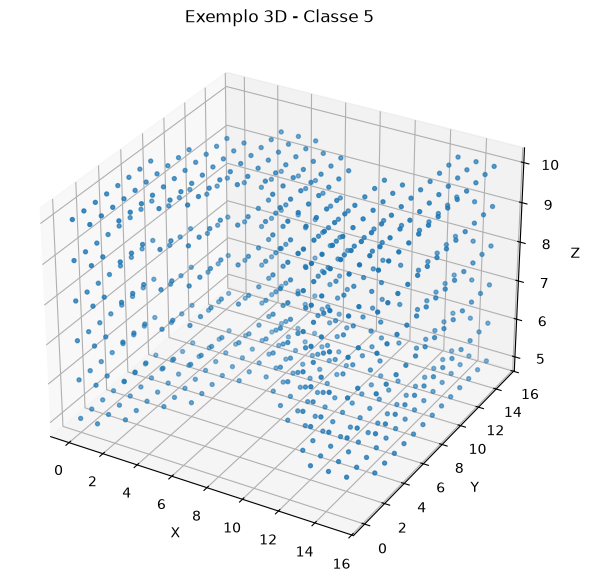

In [14]:
# Visualiza em 3D os voxels ativos de uma amostra do dataset

indice = 0
amostra_3d = X_train[indice].reshape(16, 16, 16)

x, y, z = np.where(amostra_3d > 0)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x, y, z, s=8)

ax.set_title(f"Exemplo 3D - Classe {y_train[indice]}")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [15]:
# Configura validação cruzada estratificada para preservar a proporção das classes

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


In [16]:
# Define Accuracy e F1 Macro como métricas para avaliar a classificação

metricas = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro"
}

print(metricas)

{'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}


In [17]:
# Cria uma MLP inicial com padronização dos dados para obter um desempenho de referência

pipeline = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "mlp",
        MLPClassifier(
            hidden_layer_sizes=(128,),
            activation="relu",
            solver="adam",
            learning_rate_init=0.001,
            max_iter=300,
            early_stopping=True,
            random_state=42
        )
    )
])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('mlp', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or '

In [18]:
# Avalia a MLP inicial com validação cruzada usando Accuracy e F1 Macro

resultado_baseline = cross_validate(
    pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=metricas,
    return_train_score=True,
    n_jobs=1
)

print(
    "Accuracy média:",
    resultado_baseline["test_accuracy"].mean()
)

print(
    "F1 Macro médio:",
    resultado_baseline["test_f1_macro"].mean()
)

Accuracy média: 0.6190998823937582
F1 Macro médio: 0.6129931353221751


### Desempenho da configuração inicial

A configuração inicial da MLP foi avaliada utilizando validação cruzada
estratificada com 3 folds.

Foram obtidos:

- Accuracy média: aproximadamente 61,91%
- F1 Macro médio: aproximadamente 61,30%

Esses resultados serão utilizados apenas como referência inicial para observar
o efeito posterior do ajuste de hiperparâmetros. O conjunto de teste reservado
não foi utilizado nesta etapa.

In [19]:
return_train_score=True

In [20]:
# Compara o desempenho médio da MLP nos dados de treinamento e validação

print(
    "Accuracy treino:",
    resultado_baseline["train_accuracy"].mean()
)

print(
    "Accuracy validação:",
    resultado_baseline["test_accuracy"].mean()
)

print(
    "F1 Macro treino:",
    resultado_baseline["train_f1_macro"].mean()
)

print(
    "F1 Macro validação:",
    resultado_baseline["test_f1_macro"].mean()
)

Accuracy treino: 0.947798537165851
Accuracy validação: 0.6190998823937582
F1 Macro treino: 0.9470056619331305
F1 Macro validação: 0.6129931353221751


In [21]:
# Mostra os resultados de cada fold e o desvio padrão da validação cruzada

print("Accuracy por fold:")
print(resultado_baseline["test_accuracy"])

print("\nF1 Macro por fold:")
print(resultado_baseline["test_f1_macro"])

print(
    "\nDesvio padrão da Accuracy:",
    resultado_baseline["test_accuracy"].std()
)

print(
    "Desvio padrão do F1 Macro:",
    resultado_baseline["test_f1_macro"].std()
)

Accuracy por fold:
[0.62027594 0.6189619  0.61806181]

F1 Macro por fold:
[0.61340039 0.61295904 0.61261998]

Desvio padrão da Accuracy: 0.0009091690759804942
Desvio padrão do F1 Macro: 0.00031951196255108373


In [22]:
# Lista as principais variáveis atualmente armazenadas no kernel do notebook

%whos

Variable                 Type               Data/Info
-----------------------------------------------------
ConfusionMatrixDisplay   type               <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
MLPClassifier            ABCMeta            <class 'sklearn.neural_ne<...>erceptron.MLPClassifier'>
Pipeline                 ABCMeta            <class 'sklearn.pipeline.Pipeline'>
RandomizedSearchCV       ABCMeta            <class 'sklearn.model_sel<...>arch.RandomizedSearchCV'>
StandardScaler           type               <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold          ABCMeta            <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X_test                   ndarray            2000x4096: 8192000 elems, type `float64`, 65536000 bytes (62.5 Mb)
X_train                  ndarray            10000x4096: 40960000 elems, type `float64`, 327680000 bytes (312.5 Mb)
accuracy_score           function           <function accuracy_score at 0x000001A4A211

In [23]:
# Define um estilo visual consistente para as figuras do trabalho

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})

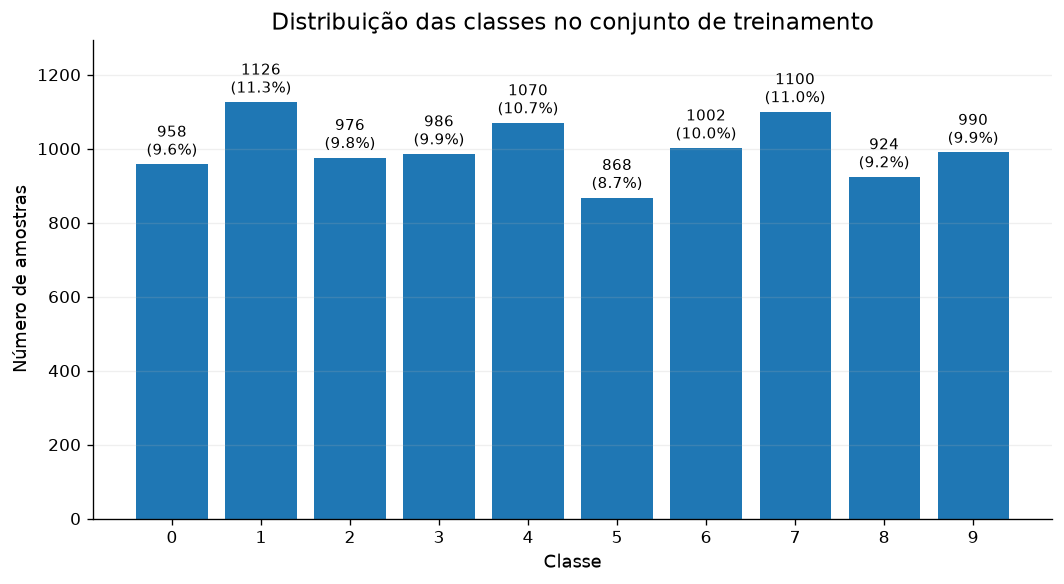

In [24]:
# Apresenta a distribuição absoluta e percentual das classes de treinamento

percentuais = quantidades / quantidades.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    classes,
    quantidades
)

ax.set_title("Distribuição das classes no conjunto de treinamento")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de amostras")
ax.set_xticks(classes)

ax.grid(
    axis="y",
    alpha=0.2
)

for barra, quantidade, percentual in zip(
    barras,
    quantidades,
    percentuais
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 12,
        f"{quantidade}\n({percentual:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_ylim(
    0,
    max(quantidades) * 1.15
)

plt.tight_layout()
plt.show()

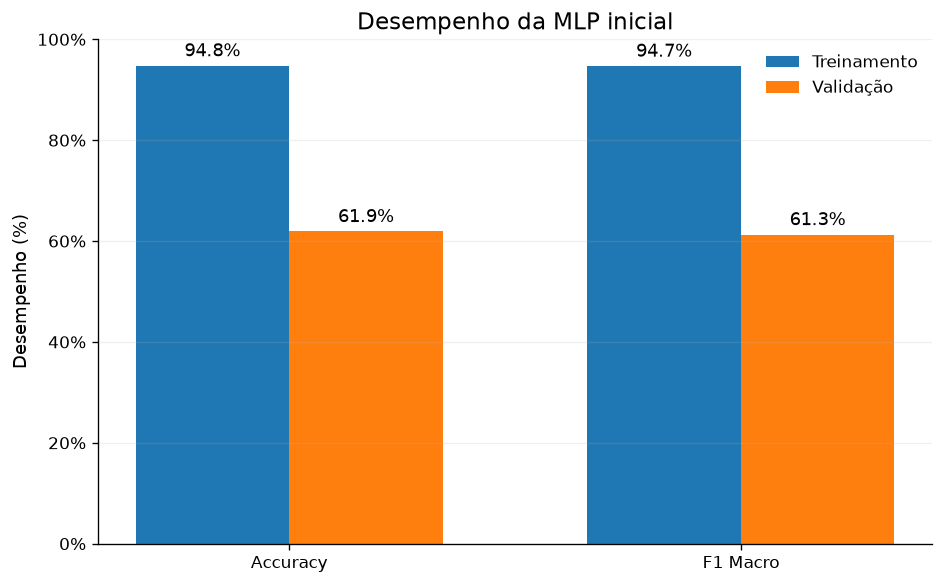

In [25]:
# Compara o desempenho da MLP no treinamento e na validação em porcentagem

nomes_metricas = [
    "Accuracy",
    "F1 Macro"
]

treinamento = np.array([
    resultado_baseline["train_accuracy"].mean(),
    resultado_baseline["train_f1_macro"].mean()
]) * 100

validacao = np.array([
    resultado_baseline["test_accuracy"].mean(),
    resultado_baseline["test_f1_macro"].mean()
]) * 100

x = np.arange(len(nomes_metricas))
largura = 0.34

fig, ax = plt.subplots(figsize=(8, 5))

barras_treino = ax.bar(
    x - largura / 2,
    treinamento,
    largura,
    label="Treinamento"
)

barras_validacao = ax.bar(
    x + largura / 2,
    validacao,
    largura,
    label="Validação"
)

ax.set_title("Desempenho da MLP inicial")
ax.set_ylabel("Desempenho (%)")

ax.set_xticks(x)
ax.set_xticklabels(nomes_metricas)

ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.legend(frameon=False)

ax.bar_label(
    barras_treino,
    fmt="%.1f%%",
    padding=3
)

ax.bar_label(
    barras_validacao,
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

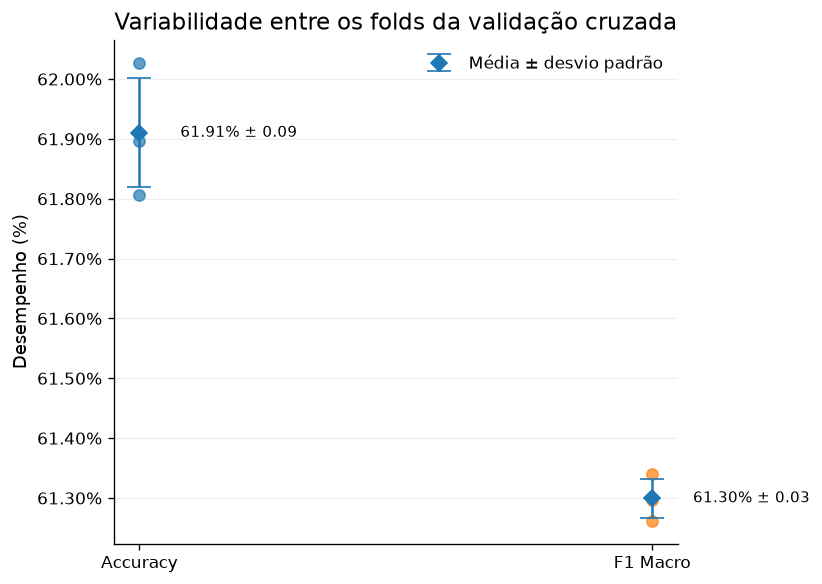

In [26]:
# Mostra os resultados individuais dos folds juntamente com média e desvio padrão

accuracy_folds = (
    resultado_baseline["test_accuracy"] * 100
)

f1_folds = (
    resultado_baseline["test_f1_macro"] * 100
)

dados_folds = [
    accuracy_folds,
    f1_folds
]

nomes = [
    "Accuracy",
    "F1 Macro"
]

medias = np.array([
    accuracy_folds.mean(),
    f1_folds.mean()
])

desvios = np.array([
    accuracy_folds.std(),
    f1_folds.std()
])

fig, ax = plt.subplots(figsize=(7, 5))

for indice, valores in enumerate(dados_folds):
    ax.scatter(
        np.full(len(valores), indice),
        valores,
        s=45,
        alpha=0.7
    )

ax.errorbar(
    np.arange(len(nomes)),
    medias,
    yerr=desvios,
    fmt="D",
    markersize=7,
    capsize=7,
    label="Média ± desvio padrão"
)

ax.set_title("Variabilidade entre os folds da validação cruzada")
ax.set_ylabel("Desempenho (%)")

ax.set_xticks(
    np.arange(len(nomes))
)

ax.set_xticklabels(nomes)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.legend(
    frameon=False
)

for i, (media, desvio) in enumerate(
    zip(medias, desvios)
):
    ax.text(
        i + 0.08,
        media,
        f"{media:.2f}% ± {desvio:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

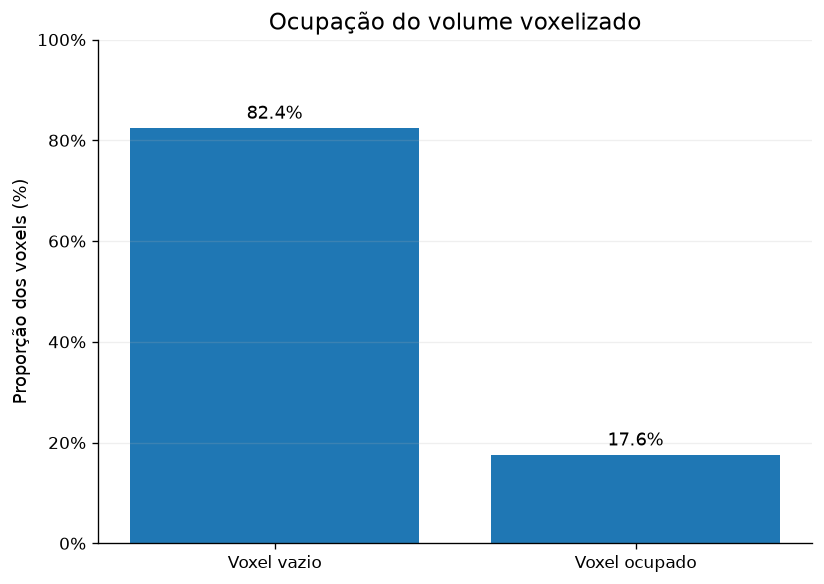

In [27]:
# Calcula e apresenta a proporção de voxels vazios e voxels com informação

total_voxels = X_train.size

voxels_zero = np.count_nonzero(
    X_train == 0
)

voxels_nao_zero = (
    total_voxels - voxels_zero
)

percentual_zero = (
    voxels_zero / total_voxels * 100
)

percentual_nao_zero = (
    voxels_nao_zero / total_voxels * 100
)

categorias = [
    "Voxel vazio",
    "Voxel ocupado"
]

percentuais = [
    percentual_zero,
    percentual_nao_zero
]

fig, ax = plt.subplots(figsize=(7, 5))

barras = ax.bar(
    categorias,
    percentuais
)

ax.set_title("Ocupação do volume voxelizado")
ax.set_ylabel("Proporção dos voxels (%)")

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.bar_label(
    barras,
    fmt="%.1f%%",
    padding=3
)

plt.tight_layout()
plt.show()

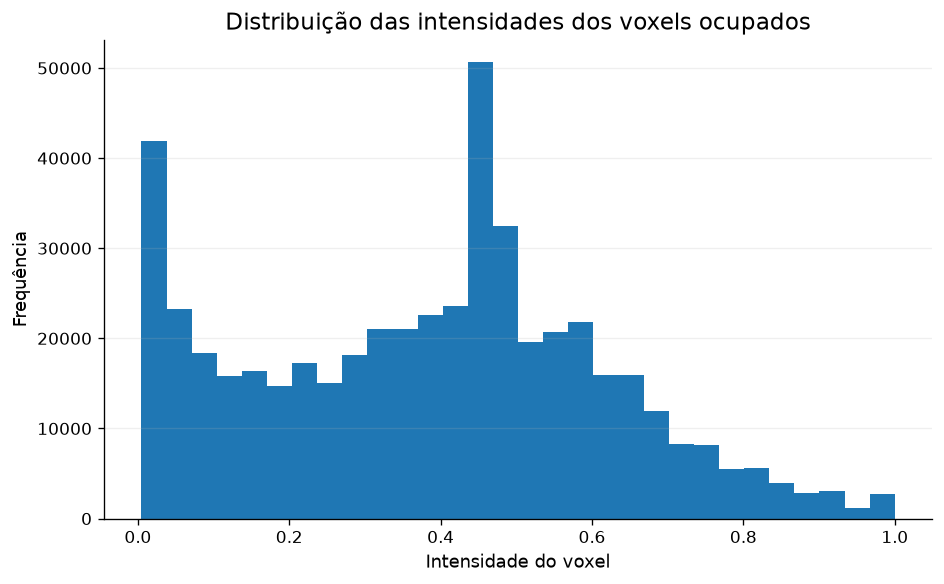

In [28]:
# Mostra a distribuição das intensidades somente dos voxels não nulos

valores_nao_zero = X_train[
    X_train > 0
]

rng = np.random.default_rng(42)

if len(valores_nao_zero) > 500000:
    valores_plot = rng.choice(
        valores_nao_zero,
        size=500000,
        replace=False
    )
else:
    valores_plot = valores_nao_zero

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    valores_plot,
    bins=30
)

ax.set_title(
    "Distribuição das intensidades dos voxels ocupados"
)

ax.set_xlabel(
    "Intensidade do voxel"
)

ax.set_ylabel(
    "Frequência"
)

ax.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [29]:
# Define o espaço de hiperparâmetros que será usado igualmente no Random Search e no TPE

espaco_busca = {
    "mlp__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64)
    ],

    "mlp__activation": [
        "relu",
        "tanh"
    ],

    "mlp__solver": [
        "adam",
        "sgd"
    ],

    "mlp__batch_size": [
        32,
        64,
        128
    ],

    "mlp__learning_rate_init": [
        0.0001,
        0.001,
        0.01
    ],

    "mlp__alpha": [
        0.0001,
        0.001,
        0.01,
        0.1
    ],

    "mlp__n_iter_no_change": [
        5,
        10,
        15
    ]
}

In [30]:
# Configura o Random Search com 25 combinações e F1 Macro como métrica principal

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=espaco_busca,
    n_iter=25,
    scoring=metricas,
    refit="f1_macro",
    cv=cv,
    random_state=42,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
    error_score="raise"
)

random_search

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'mlp__activation': ['relu', 'tanh'], 'mlp__alpha': [0.0001, 0.001, ...], 'mlp__batch_size': [32, 64, ...], 'mlp__hidden_layer_sizes': [(32,), (64,), ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",25
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These s

#Executa o Random Search e mede o tempo total da busca

import time

inicio_random = time.perf_counter()

random_search.fit(
    X_train,
    y_train
)

fim_random = time.perf_counter()

tempo_random = fim_random - inicio_random

print(
    f"Tempo total do Random Search: "
    f"{tempo_random / 60:.2f} minutos"
)

In [31]:
# Converte os dados para float32, usa 4 processos em paralelo e mede o tempo do Random Search

import time

# Reduz o consumo de memória dos dados pela metade
X_train = X_train.astype(np.float32, copy=False)
X_test = X_test.astype(np.float32, copy=False)

# Define 4 processos paralelos para o Random Search
random_search.set_params(n_jobs=4)

print("Tipo de X_train:", X_train.dtype)
print("Tipo de X_test:", X_test.dtype)
print("Processos paralelos:", random_search.n_jobs)

inicio_random = time.perf_counter()

random_search.fit(
    X_train,
    y_train
)

fim_random = time.perf_counter()

tempo_random = fim_random - inicio_random

print(
    f"\nTempo total do Random Search: "
    f"{tempo_random / 60:.2f} minutos"
)

Tipo de X_train: float32
Tipo de X_test: float32
Processos paralelos: 4
Fitting 3 folds for each of 25 candidates, totalling 75 fits

Tempo total do Random Search: 23.71 minutos


In [32]:
# Exibe os melhores hiperparâmetros encontrados pelo Random Search

print("Melhores hiperparâmetros:\n")

for parametro, valor in random_search.best_params_.items():
    print(f"{parametro}: {valor}")

print(
    f"\nMelhor F1 Macro médio: "
    f"{random_search.best_score_ * 100:.2f}%"
)

Melhores hiperparâmetros:

mlp__solver: adam
mlp__n_iter_no_change: 10
mlp__learning_rate_init: 0.001
mlp__hidden_layer_sizes: (128, 64)
mlp__batch_size: 32
mlp__alpha: 0.001
mlp__activation: relu

Melhor F1 Macro médio: 62.86%


In [33]:
# Mostra o desempenho de treino e validação da melhor configuração do Random Search

melhor_indice = random_search.best_index_

accuracy_random = random_search.cv_results_[
    "mean_test_accuracy"
][melhor_indice]

f1_random = random_search.cv_results_[
    "mean_test_f1_macro"
][melhor_indice]

f1_treino_random = random_search.cv_results_[
    "mean_train_f1_macro"
][melhor_indice]

diferenca_random = (
    f1_treino_random - f1_random
)

print(
    f"Accuracy validação: "
    f"{accuracy_random * 100:.2f}%"
)

print(
    f"F1 Macro validação: "
    f"{f1_random * 100:.2f}%"
)

print(
    f"F1 Macro treino: "
    f"{f1_treino_random * 100:.2f}%"
)

print(
    f"Diferença treino-validação: "
    f"{diferenca_random * 100:.2f} pontos percentuais"
)

Accuracy validação: 63.37%
F1 Macro validação: 62.86%
F1 Macro treino: 95.62%
Diferença treino-validação: 32.76 pontos percentuais


In [34]:
# Organiza os resultados das 25 configurações do Random Search em uma tabela

resultados_random = pd.DataFrame(
    random_search.cv_results_
)

tabela_random = resultados_random[
    [
        "rank_test_f1_macro",
        "mean_test_f1_macro",
        "std_test_f1_macro",
        "mean_test_accuracy",
        "mean_train_f1_macro",
        "param_mlp__hidden_layer_sizes",
        "param_mlp__activation",
        "param_mlp__solver",
        "param_mlp__batch_size",
        "param_mlp__learning_rate_init",
        "param_mlp__alpha",
        "param_mlp__n_iter_no_change"
    ]
].sort_values(
    "rank_test_f1_macro"
)

tabela_random.head(10)

,rank_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,mean_test_accuracy,mean_train_f1_macro,param_mlp__hidden_layer_sizes,param_mlp__activation,param_mlp__solver,param_mlp__batch_size,param_mlp__learning_rate_init,param_mlp__alpha,param_mlp__n_iter_no_change
24,1,0.628633,0.003912,0.633701,0.956226,"(128, 64)",relu,adam,32,0.0010,0.0010,10
10,2,0.618931,0.009649,0.623599,0.962095,"(128,)",relu,adam,64,0.0010,0.0100,10
8,3,0.617919,0.016114,0.623298,0.959330,"(64,)",relu,adam,64,0.0010,0.1000,10
1,4,0.613972,0.005131,0.619699,0.959796,"(128,)",relu,adam,64,0.0001,0.0100,10
23,5,0.612217,0.009199,0.618999,0.919858,"(64, 32)",relu,sgd,128,0.0100,0.1000,5
15,6,0.606341,0.005704,0.612699,0.942425,"(128,)",relu,sgd,64,0.0010,0.0001,10
16,7,0.604607,0.007885,0.610599,0.932838,"(64,)",relu,sgd,32,0.0010,0.0001,15
14,8,0.603200,0.006410,0.608900,0.925994,"(64,)",relu,sgd,32,0.0010,0.0100,10
20,9,0.602100,0.009912,0.608699,0.920765,"(128, 64)",relu,sgd,32,0.0010,0.0100,10
11,10,0.594302,0.007613,0.601699,0.879059,"(64,)",tanh,sgd,64,0.0100,0.1000,5


In [35]:
# Salva todos os resultados do Random Search em CSV para preservar os experimentos

tabela_random.to_csv(
    "resultados_random_search.csv",
    index=False
)

print("Arquivo salvo: resultados_random_search.csv")

Arquivo salvo: resultados_random_search.csv


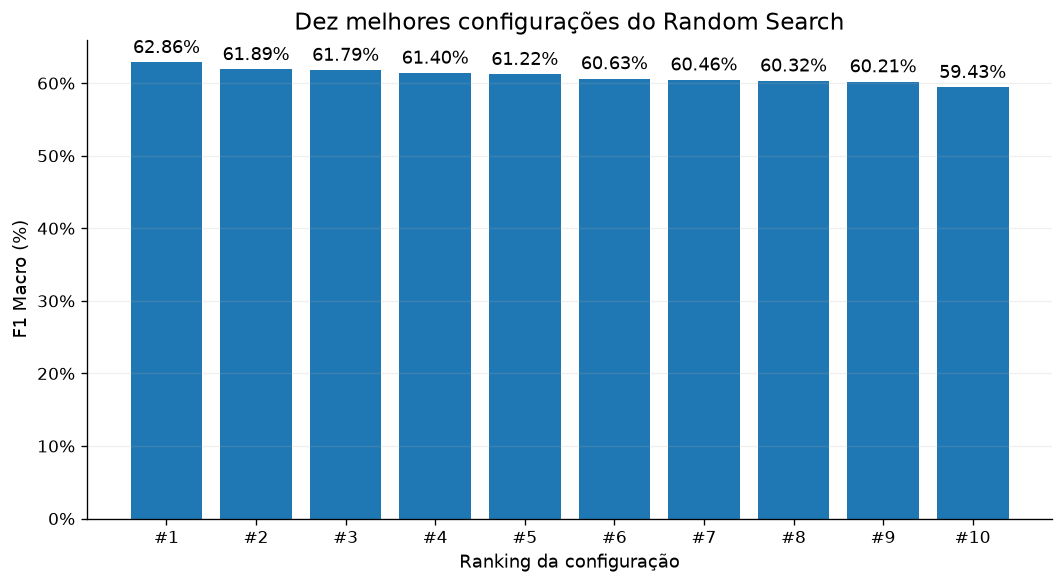

In [36]:
# Mostra o F1 Macro das dez melhores configurações encontradas pelo Random Search

top10 = tabela_random.head(10).copy()

top10["Configuração"] = [
    f"#{i}"
    for i in range(1, len(top10) + 1)
]

fig, ax = plt.subplots(figsize=(9, 5))

barras = ax.bar(
    top10["Configuração"],
    top10["mean_test_f1_macro"] * 100
)

ax.set_title(
    "Dez melhores configurações do Random Search"
)

ax.set_xlabel(
    "Ranking da configuração"
)

ax.set_ylabel(
    "F1 Macro (%)"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.bar_label(
    barras,
    fmt="%.2f%%",
    padding=3
)

plt.tight_layout()
plt.show()

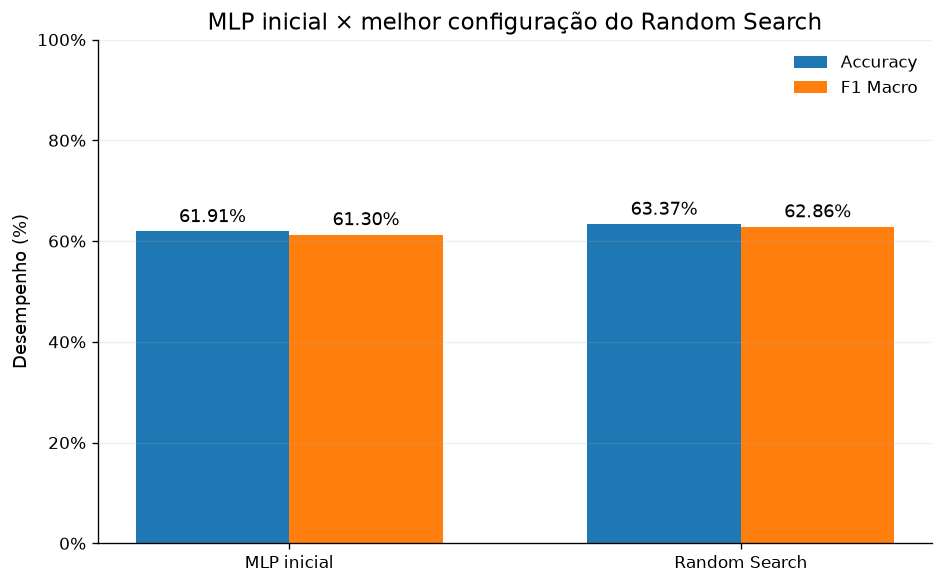

In [37]:
# Compara o desempenho de validação da MLP inicial com a melhor configuração do Random Search

nomes_modelos = [
    "MLP inicial",
    "Random Search"
]

accuracy_comparacao = [
    resultado_baseline["test_accuracy"].mean() * 100,
    accuracy_random * 100
]

f1_comparacao = [
    resultado_baseline["test_f1_macro"].mean() * 100,
    f1_random * 100
]

x = np.arange(len(nomes_modelos))
largura = 0.34

fig, ax = plt.subplots(figsize=(8, 5))

barras_accuracy = ax.bar(
    x - largura / 2,
    accuracy_comparacao,
    largura,
    label="Accuracy"
)

barras_f1 = ax.bar(
    x + largura / 2,
    f1_comparacao,
    largura,
    label="F1 Macro"
)

ax.set_title(
    "MLP inicial × melhor configuração do Random Search"
)

ax.set_ylabel(
    "Desempenho (%)"
)

ax.set_xticks(x)
ax.set_xticklabels(nomes_modelos)

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    PercentFormatter(xmax=100)
)

ax.grid(
    axis="y",
    alpha=0.2
)

ax.legend(
    frameon=False
)

ax.bar_label(
    barras_accuracy,
    fmt="%.2f%%",
    padding=3
)

ax.bar_label(
    barras_f1,
    fmt="%.2f%%",
    padding=3
)

plt.tight_layout()
plt.show()

In [41]:
# Cria o estudo Optuna utilizando o algoritmo TPE com semente fixa

sampler_tpe = optuna.samplers.TPESampler(
    seed=42
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler_tpe
)

[I 2026-10-07 23:00:42,113] A new study created in memory with name: no-name-f23244db-79e0-452f-9d0d-723c94e20783


### Resultados do Random Search

O Random Search avaliou 25 configurações de hiperparâmetros utilizando
validação cruzada estratificada com três folds e F1 Macro como métrica
principal.

A melhor configuração alcançou F1 Macro médio de aproximadamente 62,86%
e Accuracy média de aproximadamente 63,37% na validação cruzada.

Em comparação com a configuração inicial, cujo F1 Macro foi de 61,30%,
houve uma melhoria de aproximadamente 1,56 ponto percentual.

Entretanto, o F1 Macro médio no treinamento da melhor configuração foi
de aproximadamente 95,62%, resultando em uma diferença de cerca de
32,76 pontos percentuais em relação à validação. Dessa forma, permanecem
fortes indícios de overfitting.

In [47]:
# Exibe duas tabelas com os resultados do Random Search e calcula melhoria e overfitting automaticamente

import pandas as pd
from IPython.display import display, Markdown

# Índice da melhor configuração encontrada
melhor_indice = random_search.best_index_

# Resultados da MLP inicial
accuracy_inicial = resultado_baseline["test_accuracy"].mean()
f1_inicial = resultado_baseline["test_f1_macro"].mean()
f1_treino_inicial = resultado_baseline["train_f1_macro"].mean()

# Resultados da melhor configuração do Random Search
accuracy_random = random_search.cv_results_[
    "mean_test_accuracy"
][melhor_indice]

f1_random = random_search.cv_results_[
    "mean_test_f1_macro"
][melhor_indice]

f1_treino_random = random_search.cv_results_[
    "mean_train_f1_macro"
][melhor_indice]

# Recupera os melhores hiperparâmetros
melhores_parametros = random_search.best_params_


# ---------------------------------------------------------
# TABELA 1 — Melhor configuração encontrada
# ---------------------------------------------------------

tabela_melhor_configuracao = pd.DataFrame({
    "Parâmetro / Métrica": [
        "F1 Macro de validação",
        "Accuracy de validação",
        "F1 Macro de treino",
        "Arquitetura",
        "Ativação",
        "Otimizador",
        "Batch size",
        "Learning rate",
        "Alpha",
        "Paciência do Early Stopping"
    ],
    "Valor": [
        f"{f1_random * 100:.2f}%",
        f"{accuracy_random * 100:.2f}%",
        f"{f1_treino_random * 100:.2f}%",
        str(melhores_parametros["mlp__hidden_layer_sizes"]),
        melhores_parametros["mlp__activation"],
        melhores_parametros["mlp__solver"],
        melhores_parametros["mlp__batch_size"],
        melhores_parametros["mlp__learning_rate_init"],
        melhores_parametros["mlp__alpha"],
        melhores_parametros["mlp__n_iter_no_change"]
    ]
})

display(
    Markdown("### Melhor configuração encontrada pelo Random Search")
)

display(
    tabela_melhor_configuracao.style.hide(axis="index")
)


# ---------------------------------------------------------
# TABELA 2 — MLP inicial × Random Search
# ---------------------------------------------------------

tabela_comparacao = pd.DataFrame({
    "Modelo": [
        "MLP inicial",
        "Melhor Random Search"
    ],
    "Accuracy validação": [
        f"{accuracy_inicial * 100:.2f}%",
        f"{accuracy_random * 100:.2f}%"
    ],
    "F1 Macro validação": [
        f"{f1_inicial * 100:.2f}%",
        f"{f1_random * 100:.2f}%"
    ],
    "F1 Macro treino": [
        f"{f1_treino_inicial * 100:.2f}%",
        f"{f1_treino_random * 100:.2f}%"
    ]
})

display(
    Markdown("### Comparação com a MLP inicial")
)

display(
    tabela_comparacao.style.hide(axis="index")
)


# ---------------------------------------------------------
# CÁLCULOS — melhoria e overfitting
# ---------------------------------------------------------

melhoria_f1 = (
    f1_random - f1_inicial
) * 100

melhoria_accuracy = (
    accuracy_random - accuracy_inicial
) * 100

gap_overfitting = (
    f1_treino_random - f1_random
) * 100


display(
    Markdown(
        f"""
### Análise dos resultados

O Random Search melhorou o **F1 Macro em {melhoria_f1:.2f} pontos percentuais**
e a **Accuracy em {melhoria_accuracy:.2f} pontos percentuais** em relação à
configuração inicial.

Entretanto, permanece uma diferença elevada entre treinamento e validação:

**{f1_treino_random * 100:.2f}% − {f1_random * 100:.2f}% = {gap_overfitting:.2f} pontos percentuais**

Essa diferença indica que a melhor configuração encontrada pelo Random Search
ainda apresenta **fortes sinais de overfitting**.
"""
    )
)

### Melhor configuração encontrada pelo Random Search

Parâmetro / Métrica,Valor
F1 Macro de validação,62.86%
Accuracy de validação,63.37%
F1 Macro de treino,95.62%
Arquitetura,"(128, 64)"
Ativação,relu
Otimizador,adam
Batch size,32
Learning rate,0.001000
Alpha,0.001000
Paciência do Early Stopping,10


### Comparação com a MLP inicial

Modelo,Accuracy validação,F1 Macro validação,F1 Macro treino
MLP inicial,61.91%,61.30%,94.70%
Melhor Random Search,63.37%,62.86%,95.62%



### Análise dos resultados

O Random Search melhorou o **F1 Macro em 1.56 pontos percentuais**
e a **Accuracy em 1.46 pontos percentuais** em relação à
configuração inicial.

Entretanto, permanece uma diferença elevada entre treinamento e validação:

**95.62% − 62.86% = 32.76 pontos percentuais**

Essa diferença indica que a melhor configuração encontrada pelo Random Search
ainda apresenta **fortes sinais de overfitting**.


In [ ]:
# Lista as principais variáveis atualmente armazenadas no kernel do notebook

%whos

Variable                 Type               Data/Info
-----------------------------------------------------
ConfusionMatrixDisplay   type               <class 'sklearn.metrics._<...>.ConfusionMatrixDisplay'>
MLPClassifier            ABCMeta            <class 'sklearn.neural_ne<...>erceptron.MLPClassifier'>
Pipeline                 ABCMeta            <class 'sklearn.pipeline.Pipeline'>
RandomizedSearchCV       ABCMeta            <class 'sklearn.model_sel<...>arch.RandomizedSearchCV'>
StandardScaler           type               <class 'sklearn.preproces<...>ng._data.StandardScaler'>
StratifiedKFold          ABCMeta            <class 'sklearn.model_sel<...>._split.StratifiedKFold'>
X_test                   ndarray            2000x4096: 8192000 elems, type `float64`, 65536000 bytes (62.5 Mb)
X_train                  ndarray            10000x4096: 40960000 elems, type `float64`, 327680000 bytes (312.5 Mb)
accuracy_score           function           <function accuracy_score at 0x000001A4A211

In [43]:
# Define exatamente as mesmas arquiteturas usadas anteriormente no Random Search

arquiteturas = {
    "32": (32,),
    "64": (64,),
    "128": (128,),
    "64-32": (64, 32),
    "128-64": (128, 64)
}

In [44]:
# Define a função objetivo do TPE usando o mesmo espaço de busca e validação cruzada

def objective(trial):

    arquitetura_nome = trial.suggest_categorical(
        "hidden_layer_sizes",
        list(arquiteturas.keys())
    )

    activation = trial.suggest_categorical(
        "activation",
        ["relu", "tanh"]
    )

    solver = trial.suggest_categorical(
        "solver",
        ["adam", "sgd"]
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [32, 64, 128]
    )

    learning_rate_init = trial.suggest_categorical(
        "learning_rate_init",
        [0.0001, 0.001, 0.01]
    )

    alpha = trial.suggest_categorical(
        "alpha",
        [0.0001, 0.001, 0.01, 0.1]
    )

    n_iter_no_change = trial.suggest_categorical(
        "n_iter_no_change",
        [5, 10, 15]
    )

    modelo_tpe = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "mlp",
            MLPClassifier(
                hidden_layer_sizes=arquiteturas[
                    arquitetura_nome
                ],
                activation=activation,
                solver=solver,
                batch_size=batch_size,
                learning_rate_init=learning_rate_init,
                alpha=alpha,
                n_iter_no_change=n_iter_no_change,
                max_iter=300,
                early_stopping=True,
                random_state=42
            )
        )
    ])

    resultado = cross_validate(
        modelo_tpe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=3
    )

    return resultado[
        "test_score"
    ].mean()

In [45]:
# Cria o estudo Optuna utilizando o algoritmo TPE com semente fixa

sampler_tpe = optuna.samplers.TPESampler(
    seed=42
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler_tpe
)

[I 2026-10-07 23:02:05,959] A new study created in memory with name: no-name-0d3c8992-5baf-465c-8038-f599d981f62c


In [ ]:
# Executa os 25 trials do TPE e mede o tempo total da busca

import time

inicio_tpe = time.perf_counter()

study.optimize(
    objective,
    n_trials=25
)

fim_tpe = time.perf_counter()

tempo_tpe = (
    fim_tpe - inicio_tpe
)

print(
    f"Tempo total do TPE: "
    f"{tempo_tpe / 60:.2f} minutos"
)

[I 2026-10-07 23:09:59,111] Trial 3 finished with value: 0.5863188092252841 and parameters: {'hidden_layer_sizes': '64-32', 'activation': 'relu', 'solver': 'adam', 'batch_size': 64, 'learning_rate_init': 0.01, 'alpha': 0.0001, 'n_iter_no_change': 10}. Best is trial 0 with value: 0.5960082557177496.
[I 2026-10-07 23:10:10,581] Trial 4 finished with value: 0.5804323686355609 and parameters: {'hidden_layer_sizes': '32', 'activation': 'tanh', 'solver': 'sgd', 'batch_size': 32, 'learning_rate_init': 0.001, 'alpha': 0.001, 'n_iter_no_change': 5}. Best is trial 0 with value: 0.5960082557177496.
[I 2026-10-07 23:11:10,125] Trial 5 finished with value: 0.5415618553575767 and parameters: {'hidden_layer_sizes': '128', 'activation': 'relu', 'solver': 'sgd', 'batch_size': 128, 'learning_rate_init': 0.0001, 'alpha': 0.01, 'n_iter_no_change': 5}. Best is trial 0 with value: 0.5960082557177496.
[I 2026-10-07 23:13:04,377] Trial 6 finished with value: 0.5411189622083641 and parameters: {'hidden_layer_s

In [ ]:
# Exibe o melhor resultado e os melhores hiperparâmetros encontrados pelo TPE

print(
    f"Melhor F1 Macro do TPE: "
    f"{study.best_value * 100:.2f}%"
)

print(
    "\nMelhores hiperparâmetros:"
)

for parametro, valor in study.best_params.items():
    print(
        f"{parametro}: {valor}"
    )